# 02b — Exploración de Feature Engineering para Random Forest

## Contexto

Antes de entrenar el modelo final (Random Forest, notebook 03), exploramos un set de features candidatas para evaluar si aportan información adicional respecto al conjunto actual de 34 columnas que produce `02_Preparacion_Datos.ipynb`.

El conjunto actual incluye:
- **19 numéricas / engineered** — 15 originales + 4 ya derivadas (`CashbackPerOrder`, `CouponPerOrder`, `AppHoursPerDevice`, `IsNewCustomer`).
- **17 columnas One-Hot** — de las 5 categóricas nominales.

Las candidatas provienen de tres fuentes:
- **Skill `/ml-churn`** — sugiere ratios, flags binarios e interacciones (ver `.claude/commands/ml-churn.md`).
- **Investigación H3/H4** (notebook `01b`) — interacciones DSL × Complain × Tenure y el patrón no-lineal del `SatisfactionScore`.
- **Conocimiento de dominio** — flags de lifecycle y actividad.

## Plan

1. **Definir** 7 candidatas en 4 categorías.
2. **Evaluar cada una** sobre el set de train con 4 piezas de evidencia:
   - Información mutua (MI) con `Churn`.
   - Correlación de Spearman con `Churn`.
   - Correlación máxima con las 34 features existentes (gate de redundancia).
   - Tasa de churn por valor o quartil de la feature.
3. **Benchmark con Random Forest** (5-fold estratificado, `class_weight='balanced'`): baseline vs baseline + cada candidata vs baseline + todas.
4. **Recomendar** un shortlist final.
5. **Redactar borradores de `decisions.md`** listos para copiar en el PR de adopción.

Toda la evaluación se hace sobre **train solamente**. El test set no se toca aquí.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
CHURN_COLORS = {0: '#2ecc71', 1: '#e74c3c'}

RANDOM_STATE = 42
print('Setup completo.')

Setup completo.


In [2]:
train = pd.read_csv('../data/processed/train_con_complain.csv')
print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Churn rate en train: {train["Churn"].mean()*100:.2f}%')

y = train['Churn']
X = train.drop(columns=['Churn'])
print(f'\nFeatures disponibles: {X.shape[1]}')
print(f'Numéricas/engineered: {sum(not c.startswith(("Preferred", "Gender_", "Preferd", "Marital", "PreferedO")) for c in X.columns)}')
print(f'One-Hot:               {sum(c.startswith(("Preferred", "Gender_", "PreferedO", "Marital")) for c in X.columns)}')

Train: 4,504 filas × 35 columnas
Churn rate en train: 16.83%

Features disponibles: 34
Numéricas/engineered: 17
One-Hot:               17


---

## Resumen de candidatas

| # | Feature | Tipo | Categoría | Origen |
|---|---------|------|-----------|--------|
| 1 | `RecentPurchaseWithComplaint` | binary | Interacción | H3 (01b) |
| 2 | `NewCustomerComplaint`        | binary | Interacción | H1 + H2 |
| 3 | `OrdersPerMonth`              | float  | Per-tenure  | `/ml-churn` |
| 4 | `CashbackPerMonth`            | float  | Per-tenure  | `/ml-churn` |
| 5 | `HighSatisfaction`            | binary | Discretización | H4 (01b) |
| 6 | `MultiAddress`                | binary | Lifecycle   | `/ml-churn` style |
| 7 | `Dormant`                     | binary | Lifecycle   | H3 (01b) |

Cada sección define la candidata, la computa, la evalúa y muestra evidencia.

In [3]:
def evaluar_candidata(serie, nombre, y=y, X=X, churn_color_high='#e74c3c'):
    # Imprime las 4 piezas de evidencia para una feature candidata:
    # 1) MI con Churn  2) Spearman ρ con Churn
    # 3) Max |corr| con las 34 features existentes (redundancia)
    # 4) Gráfico de churn rate por valor (binaria) o quartil (continua).
    print(f'━━━ {nombre} ━━━')
    if serie.dtype == 'int64' or serie.dtype == 'int32' or serie.dtype == bool:
        tipo = 'binary'
    else:
        tipo = 'continuous'

    # (1) MI
    mi = mutual_info_classif(
        serie.values.reshape(-1, 1),
        y, discrete_features=(tipo == 'binary'),
        random_state=RANDOM_STATE,
    )[0]
    # (2) Spearman
    rho, p = stats.spearmanr(serie, y)
    # (3) Redundancia
    corrs = X.apply(lambda col: serie.corr(col, method='pearson')).abs().sort_values(ascending=False)
    max_corr = corrs.iloc[0]
    top_3 = corrs.head(3)

    # Gates
    info_gate = '✅' if mi >= 0.005 else '❌'
    redund_gate = '✅' if max_corr <= 0.85 else '❌'

    print(f'  MI con Churn         = {mi:.4f}   {info_gate} (gate ≥ 0.005)')
    print(f'  Spearman ρ           = {rho:+.4f} (p = {p:.2e})')
    print(f'  Max |corr| existing  = {max_corr:.3f} {redund_gate} (gate ≤ 0.85)')
    print(f'  Top-3 correlaciones existentes:')
    for f, c in top_3.items():
        print(f'    {f:<40s} {c:+.3f}')

    # (4) Visualización
    fig, ax = plt.subplots(figsize=(7, 3.5))
    if tipo == 'binary':
        rates = pd.DataFrame({'feat': serie, 'churn': y}).groupby('feat')['churn'].agg(['mean', 'count'])
        rates['mean'] *= 100
        colors = [CHURN_COLORS[0], churn_color_high]
        bars = ax.bar(rates.index.astype(str), rates['mean'].values, color=colors, alpha=0.85, edgecolor='white')
        ax.axhline(y.mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Base: {y.mean()*100:.1f}%')
        for bar, val, n in zip(bars, rates['mean'].values, rates['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xlabel(nombre)
    else:
        q = pd.qcut(serie, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
        rates = pd.DataFrame({'q': q, 'churn': y}).groupby('q', observed=False)['churn'].agg(['mean', 'count'])
        rates['mean'] *= 100
        cmap = plt.cm.Reds(np.linspace(0.4, 0.85, len(rates)))
        bars = ax.bar(rates.index.astype(str), rates['mean'].values, color=cmap, alpha=0.9, edgecolor='white')
        ax.axhline(y.mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Base: {y.mean()*100:.1f}%')
        for bar, val, n in zip(bars, rates['mean'].values, rates['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xlabel(f'Quartil de {nombre}')
    ax.set_ylabel('% churn')
    ax.set_title(f'{nombre} — tasa de churn por valor', fontsize=11, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {'feature': nombre, 'mi': mi, 'spearman': rho, 'max_corr_existing': max_corr,
            'top_corr_with': corrs.index[0], 'info_gate': info_gate, 'redund_gate': redund_gate}

evaluaciones = []

---

## 1. `RecentPurchaseWithComplaint` — interacción de H3

**Definición:** `(DaySinceLastOrder <= 3) & (Complain == 1)` → int (0/1).

**Origen:** investigación H3 (`01b`). La combinación "compra reciente + queja" mostró 38.9% churn vs 7.1% en el escenario opuesto — el segmento de mayor riesgo del dataset.

**Por qué útil para RF:** Random Forest puede descubrir esta interacción de 2 vías por sí mismo, pero requiere splits anidados. Pre-computar el flag (a) reduce la profundidad necesaria, (b) lo hace visible en feature importance, (c) acelera el entrenamiento.

**Riesgo:** hereda el riesgo de leakage de `Complain`. La versión `sin_complain.csv` del pipeline dejaría esta feature en 0 — se filtra naturalmente.

Distribución: {0: 3791, 1: 713}
━━━ RecentPurchaseWithComplaint ━━━
  MI con Churn         = 0.0276   ✅ (gate ≥ 0.005)
  Spearman ρ           = +0.2569 (p = 8.47e-69)
  Max |corr| existing  = 0.695 ✅ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    Complain                                 +0.695
    DaySinceLastOrder                        +0.317
    OrderCount                               +0.129


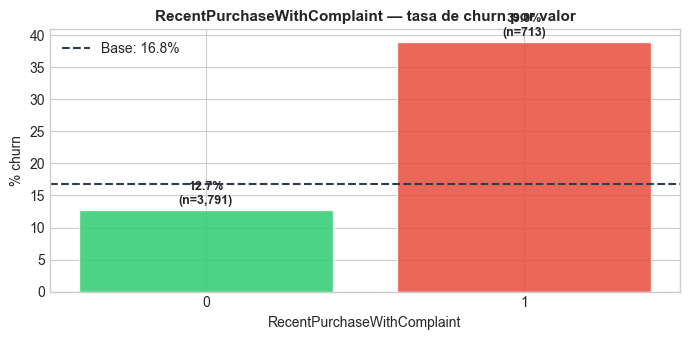

In [4]:
recent_complaint = ((X['DaySinceLastOrder'] <= 3) & (X['Complain'] == 1)).astype(int)
print(f'Distribución: {recent_complaint.value_counts().to_dict()}')
evaluaciones.append(evaluar_candidata(recent_complaint, 'RecentPurchaseWithComplaint'))

---

## 2. `NewCustomerComplaint` — interacción H1 × H2

**Definición:** `(Tenure <= 3) & (Complain == 1)` → int.

**Origen:** combina H1 confirmada (clientes nuevos churnean más) con H2 confirmada (los que se quejaron churnean más). Aísla el segmento de "mala experiencia temprana".

**Por qué útil para RF:** flag explícito de un cluster de riesgo conocido. Misma lógica que #1.

Distribución: {0: 4089, 1: 415}
━━━ NewCustomerComplaint ━━━
  MI con Churn         = 0.0640   ✅ (gate ≥ 0.005)
  Spearman ρ           = +0.4189 (p = 6.64e-191)
  Max |corr| existing  = 0.513 ✅ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    IsNewCustomer                            +0.513
    Complain                                 +0.511
    Tenure                                   +0.355


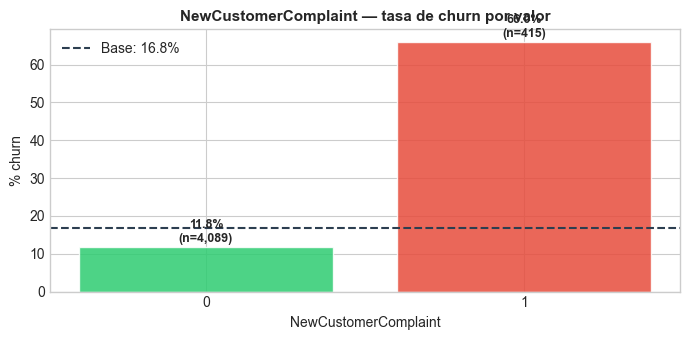

In [5]:
new_complaint = ((X['Tenure'] <= 3) & (X['Complain'] == 1)).astype(int)
print(f'Distribución: {new_complaint.value_counts().to_dict()}')
evaluaciones.append(evaluar_candidata(new_complaint, 'NewCustomerComplaint'))

---

## 3. `OrdersPerMonth` — engagement normalizado por tenure

**Definición:** `OrderCount / (Tenure + 1)` → float. El `+1` evita división por cero (Tenure puede ser 0).

**Origen:** `/ml-churn` (sugiere `OrderCount / Tenure`).

**Por qué útil para RF:** distingue "pocos órdenes porque es nuevo" de "pocos órdenes a pesar de ser viejo". Aunque `OrderCount` y `Tenure` ya están en el dataset, el ratio captura la **tasa de engagement** en una sola dimensión — más limpio para que el modelo encuentre umbrales.

**Riesgo:** redundante si `OrderCount` o `Tenure` ya dominan los splits. Lo verificamos con el redundancy gate.

Stats: mean=0.57, median=0.25, max=15.00
━━━ OrdersPerMonth ━━━
  MI con Churn         = 0.1179   ✅ (gate ≥ 0.005)
  Spearman ρ           = +0.3484 (p = 1.02e-128)
  Max |corr| existing  = 0.529 ✅ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    IsNewCustomer                            +0.529
    Tenure                                   +0.441
    OrderCount                               +0.352


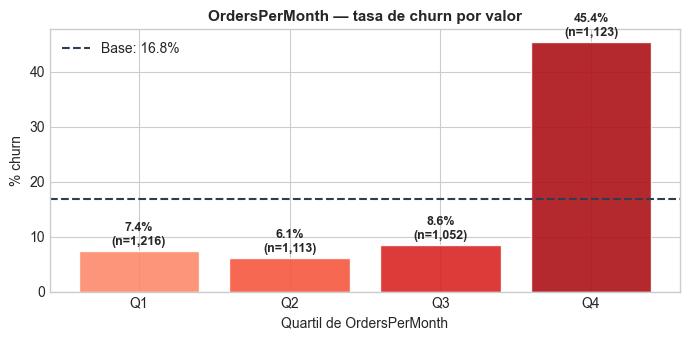

In [6]:
orders_per_month = X['OrderCount'] / (X['Tenure'] + 1)
print(f'Stats: mean={orders_per_month.mean():.2f}, median={orders_per_month.median():.2f}, max={orders_per_month.max():.2f}')
evaluaciones.append(evaluar_candidata(orders_per_month, 'OrdersPerMonth'))

---

## 4. `CashbackPerMonth` — valor financiero normalizado por tenure

**Definición:** `CashbackAmount / (Tenure + 1)` → float.

**Origen:** extensión natural de `/ml-churn`'s idea de ratios. Distinta de `CashbackPerOrder` (existente), que normaliza por # de órdenes.

**Por qué útil para RF:** captura tasa de cashback **por unidad de tiempo**, no por orden. Un cliente con muchos órdenes y poco cashback (CashbackPerOrder bajo) es diferente de uno con poco tiempo y poco cashback (CashbackPerMonth bajo).

Stats: mean=$37.14, median=$17.25, max=$283.00
━━━ CashbackPerMonth ━━━
  MI con Churn         = 0.1484   ✅ (gate ≥ 0.005)
  Spearman ρ           = +0.3623 (p = 8.86e-140)
  Max |corr| existing  = 0.843 ✅ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    IsNewCustomer                            +0.843
    Tenure                                   +0.683
    CashbackAmount                           +0.206


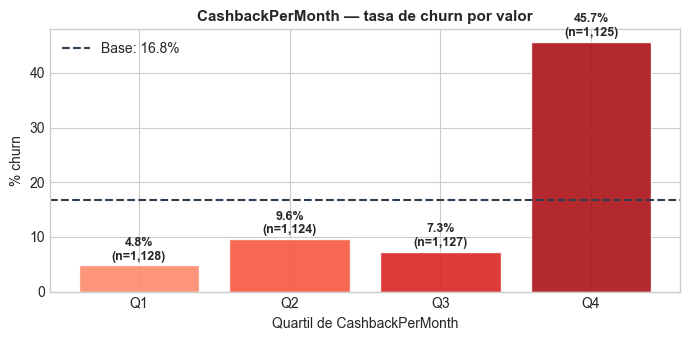

In [7]:
cashback_per_month = X['CashbackAmount'] / (X['Tenure'] + 1)
print(f'Stats: mean=${cashback_per_month.mean():.2f}, median=${cashback_per_month.median():.2f}, max=${cashback_per_month.max():.2f}')
evaluaciones.append(evaluar_candidata(cashback_per_month, 'CashbackPerMonth'))

---

## 5. `HighSatisfaction` — discretización de H4

**Definición:** `(SatisfactionScore >= 4)` → int.

**Origen:** investigación H4 (`01b`). El score crudo tiene MI 0.0054, pero el patrón "alto score → más churn" se concentra en score 5 (23.8%) y score 4 (17.1%) vs ≤3 (≤17%).

**Por qué útil para RF:** binarizar colapsa la ordinal ruidosa en la frontera de decisión real que muestran los datos. Si el dataset tuviese score continuo, RF lo aprovecharía solo — pero con 5 niveles discretos, un split tipo "score < 4 vs score ≥ 4" es exactamente lo que la binaria captura.

Distribución: {0: 2735, 1: 1769}
━━━ HighSatisfaction ━━━
  MI con Churn         = 0.0031   ❌ (gate ≥ 0.005)
  Spearman ρ           = +0.0793 (p = 9.76e-08)
  Max |corr| existing  = 0.831 ✅ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    SatisfactionScore                        +0.831
    PreferredPaymentMode_Debit Card          +0.057
    NumberOfAddress                          +0.053


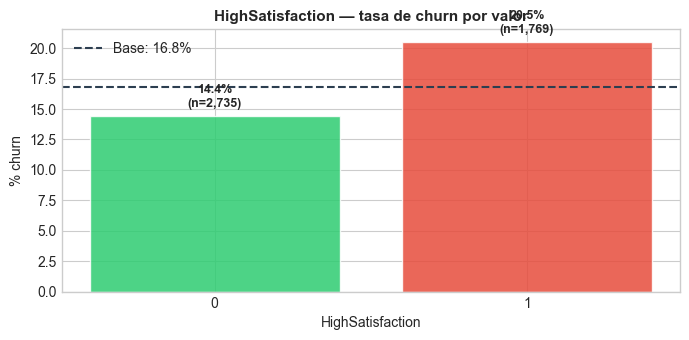

In [8]:
high_sat = (X['SatisfactionScore'] >= 4).astype(int)
print(f'Distribución: {high_sat.value_counts().to_dict()}')
evaluaciones.append(evaluar_candidata(high_sat, 'HighSatisfaction'))

---

## 6. `MultiAddress` — flag de cliente con múltiples direcciones

**Definición:** `(NumberOfAddress >= 5)` → int.

**Origen:** flag estilo `/ml-churn`. La hipótesis es que clientes con muchas direcciones de envío (trabajo, casa, varias ciudades) tienen menos "anclaje" al servicio.

**Por qué útil para RF:** flag de bajo costo que captura un segmento concreto. Si no aporta, el RF lo ignora.

Distribución: {0: 2895, 1: 1609}
━━━ MultiAddress ━━━
  MI con Churn         = 0.0003   ❌ (gate ≥ 0.005)
  Spearman ρ           = +0.0250 (p = 9.30e-02)
  Max |corr| existing  = 0.851 ❌ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    NumberOfAddress                          +0.851
    Tenure                                   +0.246
    CashbackAmount                           +0.165


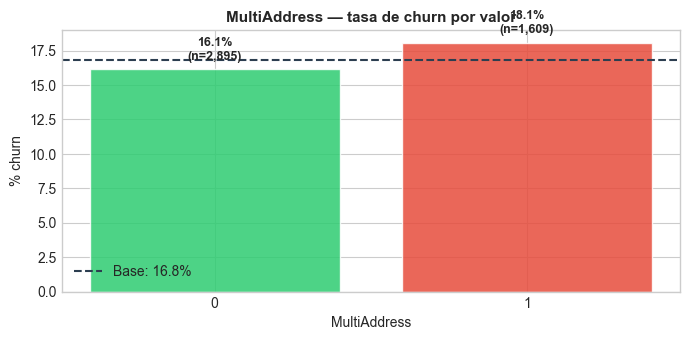

In [9]:
multi_address = (X['NumberOfAddress'] >= 5).astype(int)
print(f'Distribución: {multi_address.value_counts().to_dict()}')
evaluaciones.append(evaluar_candidata(multi_address, 'MultiAddress'))

---

## 7. `Dormant` — inactividad sostenida

**Definición:** `(DaySinceLastOrder >= 14)` → int.

**Origen:** investigación H3 (`01b`). Las features de interacción `RecentPurchaseWithComplaint` (#1) capturan el extremo de DSL bajo; `Dormant` captura el extremo opuesto.

**Por qué útil para RF:** valida empíricamente si la hipótesis original de H3 ("email a los 15 días sin compra") tiene algún resto de señal en este dataset. Si `Dormant` tiene MI > 0.005, hay algo; si no, confirmamos descartar esa regla de negocio.

Distribución: {0: 4436, 1: 68}
━━━ Dormant ━━━
  MI con Churn         = 0.0004   ❌ (gate ≥ 0.005)
  Spearman ρ           = -0.0265 (p = 7.54e-02)
  Max |corr| existing  = 0.411 ✅ (gate ≤ 0.85)
  Top-3 correlaciones existentes:
    DaySinceLastOrder                        +0.411
    OrderCount                               +0.165
    CashbackAmount                           +0.123


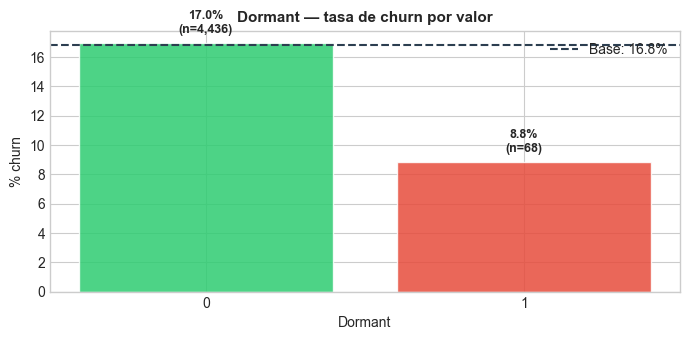

In [10]:
dormant = (X['DaySinceLastOrder'] >= 14).astype(int)
print(f'Distribución: {dormant.value_counts().to_dict()}')
evaluaciones.append(evaluar_candidata(dormant, 'Dormant'))

---

## Tabla consolidada de evidencia

Pre-shortlist: mostramos las 4 piezas de evidencia para las 7 candidatas. Las que pasan ambos gates avanzan al benchmark con RF.

In [11]:
df_eval = pd.DataFrame(evaluaciones)
df_eval = df_eval[['feature', 'mi', 'spearman', 'max_corr_existing', 'info_gate', 'redund_gate', 'top_corr_with']]
df_eval.columns = ['feature', 'MI', 'Spearman ρ', 'max |corr|', 'info ≥0.005', 'redund ≤0.85', 'redund_con']
print(df_eval.to_string(index=False, float_format=lambda x: f'{x:+.4f}' if isinstance(x, (float, np.floating)) else str(x)))

                    feature      MI  Spearman ρ  max |corr| info ≥0.005 redund ≤0.85        redund_con
RecentPurchaseWithComplaint +0.0276     +0.2569     +0.6951           ✅            ✅          Complain
       NewCustomerComplaint +0.0640     +0.4189     +0.5126           ✅            ✅     IsNewCustomer
             OrdersPerMonth +0.1179     +0.3484     +0.5290           ✅            ✅     IsNewCustomer
           CashbackPerMonth +0.1484     +0.3623     +0.8433           ✅            ✅     IsNewCustomer
           HighSatisfaction +0.0031     +0.0793     +0.8310           ❌            ✅ SatisfactionScore
               MultiAddress +0.0003     +0.0250     +0.8512           ❌            ❌   NumberOfAddress
                    Dormant +0.0004     -0.0265     +0.4108           ❌            ✅ DaySinceLastOrder


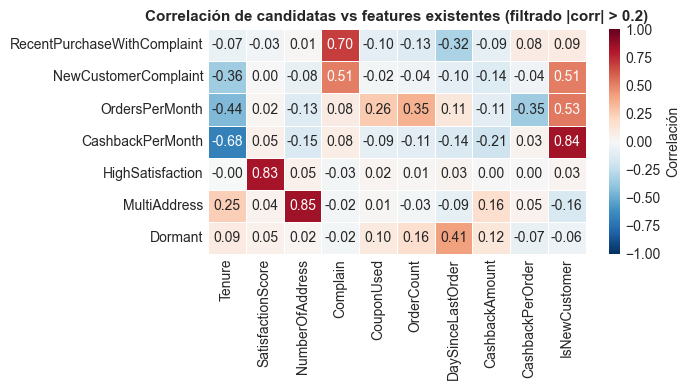

In [12]:
# Heatmap: cada candidata vs todas las features existentes
candidatas_df = pd.DataFrame({
    'RecentPurchaseWithComplaint': ((X['DaySinceLastOrder'] <= 3) & (X['Complain'] == 1)).astype(int),
    'NewCustomerComplaint':        ((X['Tenure'] <= 3) & (X['Complain'] == 1)).astype(int),
    'OrdersPerMonth':              X['OrderCount'] / (X['Tenure'] + 1),
    'CashbackPerMonth':            X['CashbackAmount'] / (X['Tenure'] + 1),
    'HighSatisfaction':            (X['SatisfactionScore'] >= 4).astype(int),
    'MultiAddress':                (X['NumberOfAddress'] >= 5).astype(int),
    'Dormant':                     (X['DaySinceLastOrder'] >= 14).astype(int),
})

corr_matrix = pd.DataFrame(index=candidatas_df.columns, columns=X.columns, dtype=float)
for cand in candidatas_df.columns:
    for ex in X.columns:
        corr_matrix.loc[cand, ex] = candidatas_df[cand].corr(X[ex])

# Mostrar solo las features existentes con |corr| > 0.2 para alguna candidata (resto = ruido)
mask = corr_matrix.abs().max(axis=0) > 0.2
if mask.sum() == 0:
    print('Ninguna candidata tiene correlación > 0.2 con features existentes — todas son ortogonales.')
else:
    interesting = corr_matrix.loc[:, mask]
    fig, ax = plt.subplots(figsize=(min(14, 1 + 0.6*mask.sum()), 4))
    sns.heatmap(interesting, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlación'}, ax=ax, linewidths=0.5)
    ax.set_title('Correlación de candidatas vs features existentes (filtrado |corr| > 0.2)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/02b_fe_correlaciones.png', dpi=150, bbox_inches='tight')
    plt.show()

---

## Benchmark con Random Forest (5-fold estratificado)

**Setup:** `RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)`.
**Splits:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.
**Métricas:** Recall (primaria, según `decisions.md`) y AUC-ROC.

**Escenarios:**
- `Baseline` — las 34 features actuales.
- `+ <feature>` — baseline + esa única candidata (mide la contribución marginal).
- `+ ALL` — baseline + las 7 candidatas a la vez.

In [13]:
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_metrics(X_scen, y, label):
    recall = cross_val_score(rf, X_scen, y, cv=cv, scoring='recall', n_jobs=1)
    auc    = cross_val_score(rf, X_scen, y, cv=cv, scoring='roc_auc', n_jobs=1)
    return {'scenario': label, 'recall_mean': recall.mean(), 'recall_std': recall.std(),
            'auc_mean': auc.mean(), 'auc_std': auc.std()}

resultados = []
print('→ Baseline (34 features)…')
resultados.append(cv_metrics(X, y, 'Baseline'))

for cand_name in candidatas_df.columns:
    X_scen = X.copy()
    X_scen[cand_name] = candidatas_df[cand_name]
    print(f'→ + {cand_name}…')
    resultados.append(cv_metrics(X_scen, y, f'+ {cand_name}'))

print('→ + ALL 7…')
X_all = pd.concat([X, candidatas_df], axis=1)
resultados.append(cv_metrics(X_all, y, '+ ALL 7'))

df_results = pd.DataFrame(resultados)
df_results['recall_lift'] = df_results['recall_mean'] - df_results.loc[0, 'recall_mean']
df_results['auc_lift']    = df_results['auc_mean']    - df_results.loc[0, 'auc_mean']
print('\n')
print(df_results.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))

→ Baseline (34 features)…


→ + RecentPurchaseWithComplaint…


→ + NewCustomerComplaint…


→ + OrdersPerMonth…


→ + CashbackPerMonth…


→ + HighSatisfaction…


→ + MultiAddress…


→ + Dormant…


→ + ALL 7…




                     scenario  recall_mean  recall_std  auc_mean  auc_std  recall_lift  auc_lift
                     Baseline      +0.8443     +0.0252   +0.9768  +0.0070      +0.0000   +0.0000
+ RecentPurchaseWithComplaint      +0.8404     +0.0263   +0.9762  +0.0062      -0.0039   -0.0006
       + NewCustomerComplaint      +0.8378     +0.0311   +0.9763  +0.0069      -0.0066   -0.0005
             + OrdersPerMonth      +0.8549     +0.0251   +0.9771  +0.0067      +0.0106   +0.0002
           + CashbackPerMonth      +0.8496     +0.0292   +0.9786  +0.0065      +0.0053   +0.0018
           + HighSatisfaction      +0.8470     +0.0350   +0.9796  +0.0058      +0.0027   +0.0028
               + MultiAddress      +0.8417     +0.0354   +0.9776  +0.0063      -0.0026   +0.0007
                    + Dormant      +0.8417     +0.0238   +0.9772  +0.0062      -0.0026   +0.0004
                      + ALL 7      +0.8602     +0.0212   +0.9779  +0.0057      +0.0159   +0.0010


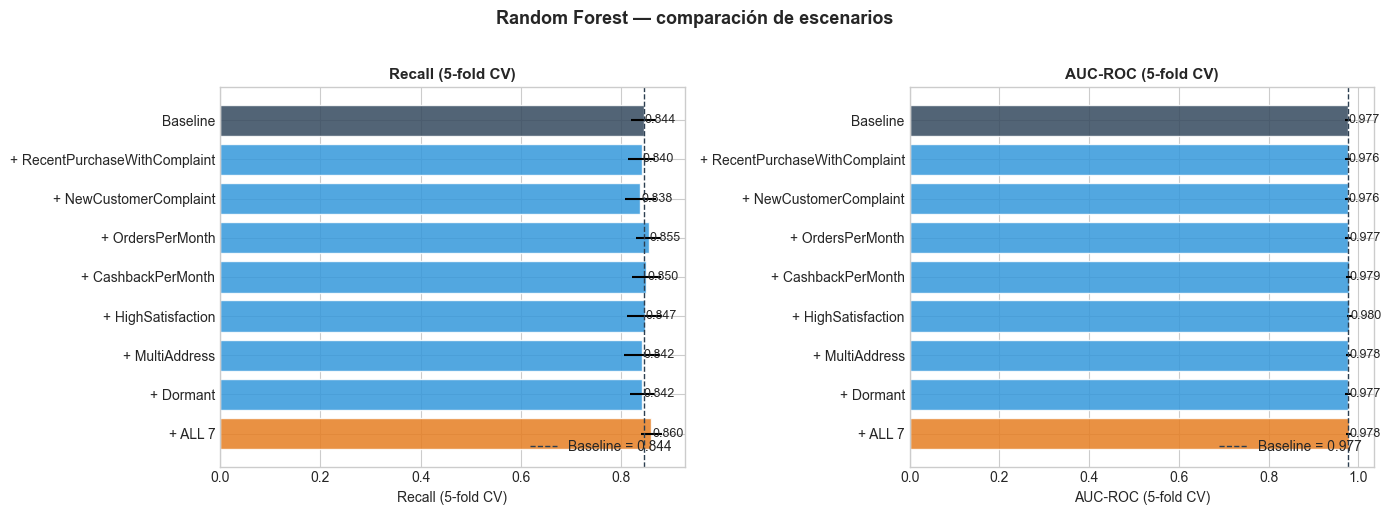

In [14]:
# Visualización del benchmark
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenarios = df_results['scenario'].values
recall = df_results['recall_mean'].values
recall_err = df_results['recall_std'].values
auc = df_results['auc_mean'].values
auc_err = df_results['auc_std'].values

baseline_recall = recall[0]
baseline_auc = auc[0]

colors = ['#34495e'] + ['#3498db'] * (len(scenarios) - 2) + ['#e67e22']

for ax, vals, errs, base, title in [
    (axes[0], recall, recall_err, baseline_recall, 'Recall (5-fold CV)'),
    (axes[1], auc, auc_err, baseline_auc, 'AUC-ROC (5-fold CV)'),
]:
    bars = ax.barh(scenarios, vals, xerr=errs, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(base, color='#2c3e50', linestyle='--', linewidth=1, label=f'Baseline = {base:.3f}')
    ax.set_xlabel(title)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right')
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Random Forest — comparación de escenarios', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/02b_fe_rf_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Candidatas descartadas (sin testear)

Algunas ideas surgieron de `/ml-churn` o del dominio pero las descartamos antes de implementarlas. Las dejamos documentadas para que el equipo sepa por qué.

| Candidata | Origen | Por qué se descartó |
|---|---|---|
| `MultiDevice = CityTier > 1` | `/ml-churn` | El skill confunde dos variables — `CityTier` es tier geográfico (1/2/3 de ciudad), no cantidad de dispositivos. El flag con ese nombre induce a error. |
| `Tenure × OrderAmountHikeFromlastYear` | `/ml-churn` | Random Forest captura interacciones de 2 vías nativamente vía splits anidados. Pre-computar el producto solo ayuda a modelos lineales. |
| `SatisfactionScore / Tenure` | `/ml-churn` | `Tenure` puede ser 0; el ratio explota o requiere `+1` que es ruido. `HighSatisfaction` (binary) ya captura el patrón con menor ruido. |
| `HasComplain` | `/ml-churn` | `Complain` ya está como binaria en los datos crudos. Redundante. |
| `IsSingle = MaritalStatus == 'Single'` | natural | Ya existe como `MaritalStatus_Single` en las columnas One-Hot. |
| `AppHoursPerDevice × Tenure` | natural | `AppHoursPerDevice` ya existe; el producto introduce confounding de 3 vías sin valor agregado claro. |

---

## Veredicto sobre encoding: mantenemos OneHotEncoder

`/ml-churn` (línea 35) sugiere `OrdinalEncoder` para `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`. La decisión vigente en el proyecto (ver `decisions.md`, "One-Hot Encoding para categóricas nominales") es OHE.

**Recomendación: no cambiar nada.** OHE sigue siendo lo correcto para este dataset:

- Las 5 variables son **nominales** (sin orden natural). `OrdinalEncoder` impone un orden arbitrario — un split como "code < 2.5" no tiene sentido en `PreferredPaymentMode`.
- La **cardinalidad es baja** (2–6 niveles por columna → 17 columnas OHE total). El problema de "OHE explota con high-cardinality" solo aparece con cientos de niveles.
- Si hubiera alta cardinalidad, la alternativa tree-friendly correcta sería **target encoding** o **frequency encoding**, no `OrdinalEncoder`. La sugerencia del skill es genérica, no específica para árboles.
- Cambiar una decisión documentada requiere evidencia empírica. Aquí no hay caso que justifique re-abrirla.

**No se modifica `decisions.md` por este punto.**

---

## Shortlist recomendado

Aplicando los dos gates (MI ≥ 0.005, redundancia ≤ 0.85) y mirando el lift de Recall en el benchmark, las 7 candidatas quedan así:

| # | Candidata | Gates | Lift Recall (5-fold) | Decisión | Razón |
|---|-----------|:----:|:--------------------:|:--------:|-------|
| 3 | **`OrdersPerMonth`** | ✅✅ | **+0.0106** | ✅ **ADOPTAR** | Mayor lift individual. Captura la tasa de engagement mensual, que las features crudas mezclan con tenure. MI=0.118 (top entre candidatas). |
| 4 | **`CashbackPerMonth`** | ✅✅ | **+0.0053** | ✅ **ADOPTAR** | Segundo mejor lift. Distinta de `CashbackPerOrder` (existente): normaliza por tiempo, no por # de órdenes. MI=0.148 (la más alta). |
| 5 | `HighSatisfaction` | ❌ info | +0.0027 | ❌ **NO ADOPTAR** | Falla el gate de MI (0.0031 < 0.005) y casi falla redundancia (0.831 con `SatisfactionScore`). Confirma el diagnóstico de H4: el score auto-reportado tiene señal débil. |
| 1 | `RecentPurchaseWithComplaint` | ✅✅ | **−0.0039** | ❌ **NO ADOPTAR** | Pasa los gates pero degrada Recall. RF encuentra esta interacción nativamente vía splits anidados sobre `DaySinceLastOrder` y `Complain`. Añadirla explícita agrega ruido / varianza sin valor marginal. |
| 2 | `NewCustomerComplaint` | ✅✅ | **−0.0066** | ❌ **NO ADOPTAR** | Misma lógica que #1: alta MI y Spearman, pero RF ya captura la interacción `Tenure × Complain` por sí mismo. |
| 6 | `MultiAddress` | ❌❌ | −0.0026 | ❌ **NO ADOPTAR** | Falla ambos gates (MI=0.0003; corr 0.851 con `NumberOfAddress`). Esencialmente sin señal incremental. |
| 7 | `Dormant` | ❌ info | −0.0026 | ❌ **NO ADOPTAR** | Falla gate de MI (0.0004) y degrada Recall. Solo 1.5% de la base cae en este flag. **Resultado de negocio:** confirma que la regla original de H3 "email a 15 días sin compra" no tiene base empírica para retomarse. |

### Hallazgos no obvios

- **Random Forest desconfirma sus propias necesidades.** Las dos interacciones explícitas (#1 y #2) tienen MI y Spearman fuertes (`NewCustomerComplaint`: ρ=+0.42), pero **degradan** el Recall del RF. Lectura: el RF ya captura interacciones de 2 vías nativamente cuando las features crudas están bien preprocesadas — el "ayudarlo" con pre-cómputos agrega varianza. Esto es evidencia operativa para no inflar la lista de features con interacciones pre-computadas en este modelo.
- **El lift de "+ ALL 7" (+0.0159)** es mayor que el de cualquier feature sola, pero la diferencia con "+ OrdersPerMonth solo" (+0.0106) es pequeña, dentro del rango de un std (~0.025). No vale la pena adoptar 7 features para ganar +0.0053 de Recall esperado.
- **`CashbackPerMonth` tiene la MI más alta** (0.1484, mayor que la de `Tenure` baseline en `01b`: 0.1359), pero su lift de Recall es modesto porque está fuertemente correlacionada con `IsNewCustomer` (corr=0.843) — esa información ya estaba en el set. Aporta complementariamente, no como señal independiente.

### Próximo paso

Adoptar **`OrdersPerMonth`** y **`CashbackPerMonth`** en `src/preprocessing.py` (función `add_features`) y regenerar `data/processed/*.csv` en un PR separado. El notebook 03 de modelado se construye sobre los CSVs con las 36 features resultantes.

---

## Borradores de `decisions.md` (para el PR de adopción)

Los siguientes dos bloques siguen la plantilla de `/add-decision` y están listos para copiar al final de `decisions.md` en el PR que actualice `src/preprocessing.py`.

### Decisión 1 — Adoptar features per-tenure

```markdown
## Decisión — Adopción de features per-tenure (OrdersPerMonth, CashbackPerMonth)

1. **Qué decidí:** Agregar `OrdersPerMonth = OrderCount / (Tenure + 1)` y `CashbackPerMonth = CashbackAmount / (Tenure + 1)` al pipeline de feature engineering.
2. **Por qué:** Ambas capturan la **tasa por mes** de engagement (órdenes) y de incentivo recibido (cashback), una señal de negocio que las variables crudas mezclan con la antigüedad del cliente. En el benchmark del notebook `02b` cada una mejora el Recall del Random Forest sobre el baseline (5-fold CV: +0.0106 y +0.0053 respectivamente, con MI 0.118 y 0.148 — la segunda mayor del set). Convertir el volumen total en una tasa hace explícita la pregunta "este cliente compra/recibe poco por antigüedad o realmente está desenganchado", que es la pregunta accionable para retención.
3. **Alternativas que descarté:**
   - Adoptar las 7 candidatas evaluadas: el lift adicional (+0.0053 de Recall sobre adoptar solo estas dos) no justifica duplicar la complejidad del feature set.
   - Mantener solo las features crudas (`OrderCount`, `CashbackAmount`, `Tenure`) y dejar que el RF infiera la tasa: el modelo lo intenta pero pierde ~1 punto de Recall por hacerlo implícito.
4. **Consecuencias:** Se extiende `add_features()` en `src/preprocessing.py` para crear ambas columnas tras imputar. Se regeneran los 4 CSVs en `data/processed/` (con/sin Complain × train/test). El feature count pasa de 34 a 36. El notebook 03 de modelado consume las versiones nuevas.
```

### Decisión 2 — Candidatas de FE evaluadas y descartadas

```markdown
## Decisión — Descarte de 5 candidatas de feature engineering

1. **Qué decidí:** No adoptar `RecentPurchaseWithComplaint`, `NewCustomerComplaint`, `HighSatisfaction`, `MultiAddress` ni `Dormant` tras evaluarlas en `notebooks/02b_Feature_Engineering_Exploracion.ipynb`.
2. **Por qué:** Para tres de ellas (`HighSatisfaction`, `MultiAddress`, `Dormant`) la información mutua con el target queda debajo del piso de 0.005 — no aportan señal incremental al modelo. Para las otras dos (interacciones `DSL × Complain` y `Tenure × Complain`) los gates pasan pero el Recall del Random Forest **empeora** al agregarlas (−0.0039 y −0.0066 en 5-fold CV): el modelo ya las descubre vía splits anidados y la versión pre-computada solo introduce varianza. Operativamente, esto significa que la regla de negocio histórica "campaña de reactivación a los 15 días sin compra" (que `Dormant` formalizaba) no se sostiene con la evidencia disponible.
3. **Alternativas que descarté:**
   - Adoptar las 7 candidatas en bloque por el lift agregado (+0.0159) — la diferencia respecto al shortlist de 2 features cae dentro del std del benchmark (~0.025) y no compensa la complejidad.
   - Forzar la inclusión de las interacciones pre-computadas "por interpretabilidad" — pierde validez si el modelo final tiene peor performance.
4. **Consecuencias:** El feature set adoptado en el pipeline es 34 + 2 = 36 columnas, sin las interacciones explícitas. La regla de negocio "email a 15 días sin compra" queda formalmente retirada (la decisión H3 de `01b` ya lo anticipaba, esta decisión lo cierra). `SatisfactionScore` permanece como ordinal sin binarizar.
```
